<a href="https://colab.research.google.com/github/nwon24/nlp/blob/main/BERT_for_W8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine tuning a BERT model for text classification

BERT (Bidirectional encoder representations from transformers) is a special kind of transfomer architecture that has wide applications in NLP.

# Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader,Dataset
from torch.optim import Adam
from torch.nn import BCEWithLogitsLoss,BCELoss
from torch import accelerator
from torch import tensor
from torch.nn import Sigmoid
from transformers import BertForSequenceClassification
from transformers import AutoTokenizer


Here it's handy as well to set a variable that will hold the device we want to train the model on. That way we don't have to manually change the device if we no longer have  GPU.

In [2]:
device=accelerator.current_accelerator().type if accelerator.is_available() else "cpu"

# Hyperparameters

In [3]:
batch_size=32
lr=1e-5
epochs=1

# Data preparation and tokenisation

Our corpus is a CSV file of Amazon reviews eith three columns: label, title of the review, and the text of the review itself.

For the tokeniser, we are lucky to have a pretrained tokeniser from `AutoTokenizer`. This tokenizer returns the tokens of the corpus in a special dictionary, which will be used in the `DataLoader` class to feed the input correctly into the model. The output of the tokenizer is a dictionary with keys `input_ids`, `token_type_ids`, and `attention_mask`, so we can't just use our homeegrown tokenizer or that of `CounntVectorizer` anymore. We can, however, still use the `LabelEncoder` from `sklearn` to convert our labels into ones and zeroes.




In [4]:
corpus_file="xaa"
data=pd.read_csv(corpus_file,encoding="utf-8")
trainX,testX,trainY,testY=train_test_split(data["text"],data["label"],test_size=0.2)

label_encoder=LabelEncoder()

tokenizer=AutoTokenizer.from_pretrained("google-bert/bert-base-cased")
train_tokens=tokenizer(list(trainX),truncation=True,padding=True)
test_tokens=tokenizer(list(testX),truncation=True,padding=True)
train_labels=label_encoder.fit_transform(trainY)
test_labels=label_encoder.transform(testY)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Loading the data

Models implemented in `torch` can be trained by feeding input data through the `DataLoader` and `DataSet` classes. This ensures that the data comes in the specified batches and that the data is also shuffled around.

To implement our own class that inherits from `DataLoader`, we just need to define a copy of basic methods: a method to return the amount of data we have, and a method to return the both the input and and the corresponding output given an index. In this case we have included the labels in the dictionary that is returned, but we could also have returned the labels separately.

In [5]:
class token_data(Dataset):
    def __init__(self,data,tokens,labels):
        # self.data will hold raw data (not tokenized) for __len__ method
        self.data=data
        self.tokens=tokens
        self.labels=labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):
        item={}
        for k,v in self.tokens.items():
            item[k]=tensor(v[idx])
        item["labels"]=tensor(self.labels[idx]).float()
        return item

Now that we have our  own `token_data` class, all that is required is to wrap our data using the `DataLoader` class.

In [11]:
train_loader=DataLoader(token_data(trainX,train_tokens,train_labels),shuffle=True,batch_size=batch_size)
test_loader=DataLoader(token_data(testX,test_tokens,test_labels),shuffle=False,batch_size=batch_size)

# Loading the pretrained BERT model

We use binary cross entropy loss because our classification task is binary---the reviews are either positive or negative.

In [7]:
model=BertForSequenceClassification.from_pretrained("google-bert/bert-base-cased",num_labels=1).to(device)
optimizer=Adam(model.parameters(),lr=lr)
loss_fn=BCEWithLogitsLoss()

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Training


In [8]:
model.train()

for epoch in range(epochs):
    batch_loss=0
    for i,batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids=batch["input_ids"].to(device)
        attention_mask=batch["attention_mask"].to(device)
        labels=batch["labels"].to(device)

        prediction=model(input_ids,attention_mask=attention_mask)
        loss=loss_fn(prediction.logits.flatten(),labels)
        loss.backward()
        optimizer.step()

        batch_loss+=loss.item()
        current_loss=loss.item()
        print(f"Batch {i}, loss {current_loss:.6f}")
    print(f"Epoch {epoch}, loss {batch_loss/batch_size:.6f}")

Batch 0, loss 0.714502
Batch 1, loss 0.696422
Batch 2, loss 0.700372
Batch 3, loss 0.700055
Batch 4, loss 0.709978
Batch 5, loss 0.733323
Batch 6, loss 0.682234
Batch 7, loss 0.711030
Batch 8, loss 0.719561
Batch 9, loss 0.700563
Batch 10, loss 0.679529
Batch 11, loss 0.706622
Batch 12, loss 0.691504
Batch 13, loss 0.709072
Batch 14, loss 0.682243
Batch 15, loss 0.676705
Batch 16, loss 0.678476
Batch 17, loss 0.692522
Batch 18, loss 0.675347
Batch 19, loss 0.723022
Batch 20, loss 0.662357
Batch 21, loss 0.663405
Batch 22, loss 0.693735
Batch 23, loss 0.663812
Batch 24, loss 0.675045
Batch 25, loss 0.683748
Batch 26, loss 0.671709
Batch 27, loss 0.660058
Batch 28, loss 0.662802
Batch 29, loss 0.673345
Batch 30, loss 0.643629
Batch 31, loss 0.654271
Batch 32, loss 0.659662
Batch 33, loss 0.700711
Batch 34, loss 0.657749
Batch 35, loss 0.613969
Batch 36, loss 0.649327
Batch 37, loss 0.633583
Batch 38, loss 0.629161
Batch 39, loss 0.619753
Batch 40, loss 0.592811
Batch 41, loss 0.625053
Ba

# Testing

To turn the predictions back into labels, we need to apply the `Sigmoid()` activation function on the `logits` of the prediction. This is because the `logit` function is the inverse of the `Sigmoid` function.

Batch 0, loss 0.002208
Accuracy: 0.96875
Batch 1, loss 0.002263
Accuracy: 0.96875
Batch 2, loss 0.007142
Accuracy: 0.95833
Batch 3, loss 0.002661
Accuracy: 0.96094
Batch 4, loss 0.008472
Accuracy: 0.95000
Batch 5, loss 0.008615
Accuracy: 0.94271
Batch 6, loss 0.005886
Accuracy: 0.94643
Batch 7, loss 0.002257
Accuracy: 0.94922
Batch 8, loss 0.001954
Accuracy: 0.95139
Batch 9, loss 0.014946
Accuracy: 0.94063
Batch 10, loss 0.008197
Accuracy: 0.93466
Batch 11, loss 0.002830
Accuracy: 0.93490
Batch 12, loss 0.007907
Accuracy: 0.93269
Batch 13, loss 0.009236
Accuracy: 0.93304
Batch 14, loss 0.006364
Accuracy: 0.93333
Batch 15, loss 0.005899
Accuracy: 0.93164
Batch 16, loss 0.004319
Accuracy: 0.93382
Batch 17, loss 0.004682
Accuracy: 0.93576
Batch 18, loss 0.001862
Accuracy: 0.93914
Batch 19, loss 0.001911
Accuracy: 0.94063
Batch 20, loss 0.005895
Accuracy: 0.94048
Batch 21, loss 0.012399
Accuracy: 0.93750
Batch 22, loss 0.010091
Accuracy: 0.93478
Batch 23, loss 0.004177
Accuracy: 0.93490
Ba

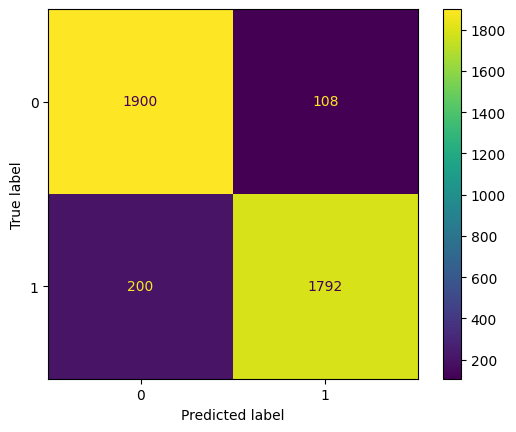

In [12]:
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
correct = 0
preds=[]
for i,batch in enumerate(test_loader):
    input_ids=batch["input_ids"].to(device)
    attention_mask=batch["attention_mask"].to(device)
    labels=batch["labels"].to(device)

    with torch.no_grad():
        prediction=model(input_ids,attention_mask=attention_mask)
    loss=loss_fn(prediction.logits.flatten(),labels)
    batch_loss=loss.item()
    print(f"Batch {i}, loss {batch_loss/batch_size:.6f}")
    pred=torch.round(Sigmoid()(prediction.logits.flatten()))
    preds.append(pred.to("cpu"))
    correct+=(pred==labels).sum().item()
    print(f"Accuracy: {correct/((i+1)*batch_size):.5f}")

preds=np.hstack(preds)
f1=f1_score(test_loader.dataset.labels,np.round(preds))
print(f"F1 score = {f1}")
ConfusionMatrixDisplay.from_predictions(test_loader.dataset.labels,np.round(preds))
plt.show()
